# Negative day-ahead prices in Germany

The German/Luxembourg day-ahead auction price (`smard_price_de_lu`, EPEX
Spot, naive UTC timestamps), already used elsewhere in this book
(`07_ttf_gas_vs_power_price`, `10_pv_capture_rate`,
`11_price_bimodality`), occasionally goes negative -- generation exceeds
demand by enough that producers pay to keep feeding in rather than
curtail. This page asks four questions about how that behaviour is
evolving:

1. How many hours per year are negative, and is there a trend?
2. When do negative hours happen -- which hour of day, which month?
3. Has the month-of-year pattern itself shifted over the years (heatmap)?
4. How long do negative-price spells last -- one hour, or many in a row?

Prototyped in `energy-research`'s exploratory pipeline
(`11_negative_day_ahead_prices`) before being rebuilt here against this
hub's own `smard_price_de_lu` output -- see that repo's PROJECT.md for
the original investigation, including a cross-check against
Bundesnetzagentur / press-reported hours-per-year figures for 2022-2025
(exact match for 2024 and 2025, within a couple of hours for the earlier
years).

**Partial-year caveat, carried through every chart below:** the series
starts 2018-09-30 and the most recent year is cut off at today's data
(see the hub's SMARD asset docs) -- both edge years cover fewer hours
than a full year and are marked with a lighter bar wherever a per-year
total is shown. Any trend statement below is computed only on full
calendar years.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from insights.paths import hub_file

# dataviz skill categorical slot 1 (blue) -- single series throughout this
# page, so every chart reuses the same hue rather than cycling colors.
MAIN_COLOR = "#2a78d6"
# Sequential-ramp step 250 for the same hue -- the lightest step that still
# clears the ordinal 2:1 contrast floor -- used to mark partial-year bars.
PARTIAL_COLOR = "#86b6ef"
NEUTRAL = "#898781"  # dataviz skill muted ink (axis/labels)
# Sequential blue ramp, documented steps 100->700 (dataviz skill palette.md)
MAIN_CMAP = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
FULL_YEARS = range(2019, pd.Timestamp.today().year)  # excludes the two partial edge years

## Data

In [2]:
price = pd.read_parquet(hub_file("smard", "price_de_lu.parquet"))
price.index = pd.to_datetime(price.index)
price = price["price_de_lu"]

is_neg = price < 0

print(f"{len(price):,} hourly prices, {price.index.min()} -> {price.index.max()} (naive UTC)")
print(f"{is_neg.sum():,} negative hours overall ({is_neg.mean() * 100:.2f}% of all hours)")

69,984 hourly prices, 2018-09-30 22:00:00 -> 2026-09-24 21:00:00 (naive UTC)
2,530 negative hours overall (3.62% of all hours)


## 1. Negative hours per year -- level and trend

Left: raw count of negative hours per calendar year (the partial first
and last-year bars are lighter). Right: the same thing as a *share* of
that year's hours, which is the fair way to compare a partial year
against a full one -- a linear trend (dashed) is fit on full years only.

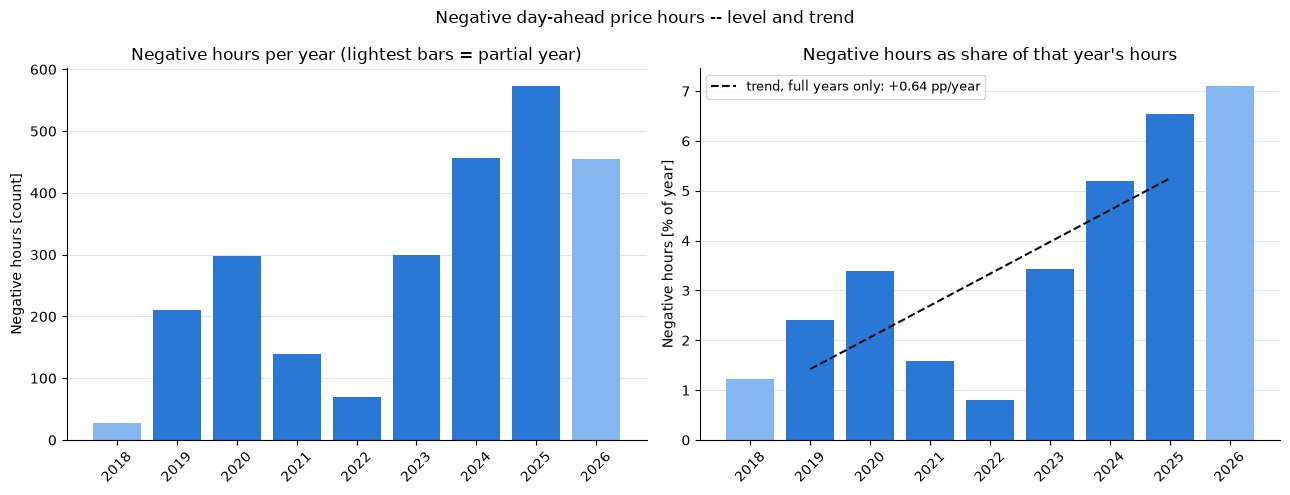

           neg_hours  total_hours  share_pct
timestamp                                   
2018              27         2210       1.22
2019             211         8760       2.41
2020             298         8784       3.39
2021             139         8760       1.59
2022              70         8760       0.80
2023             300         8760       3.42
2024             457         8784       5.20
2025             573         8760       6.54
2026             455         6406       7.10

Linear trend (full years only): +0.638 percentage points / year


In [3]:
by_year = pd.DataFrame({
    "neg_hours": is_neg.groupby(is_neg.index.year).sum(),
    "total_hours": price.groupby(price.index.year).size(),
})
by_year["share_pct"] = by_year["neg_hours"] / by_year["total_hours"] * 100

years = by_year.index
partial_mask = (years == years.min()) | (years == years.max())
bar_colors = [PARTIAL_COLOR if p else MAIN_COLOR for p in partial_mask]

fit_years = by_year.index.isin(FULL_YEARS)
slope, intercept = np.polyfit(by_year.index[fit_years], by_year["share_pct"][fit_years], 1)
trend_x = by_year.index[fit_years]
trend_y = slope * trend_x + intercept

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(years.astype(str), by_year["neg_hours"].values, color=bar_colors)
axes[0].set_title("Negative hours per year (lightest bars = partial year)")
axes[0].set_ylabel("Negative hours [count]")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(years.astype(str), by_year["share_pct"].values, color=bar_colors)
axes[1].plot(trend_x.astype(str), trend_y, color="#0b0b0b", linestyle="--", linewidth=1.5,
             label=f"trend, full years only: {slope:+.2f} pp/year")
axes[1].set_title("Negative hours as share of that year's hours")
axes[1].set_ylabel("Negative hours [% of year]")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=9, loc="upper left")

for ax in axes:
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Negative day-ahead price hours -- level and trend", fontsize=12)
fig.tight_layout()
plt.show()

print(by_year.round(2).to_string())
print(f"\nLinear trend (full years only): {slope:+.3f} percentage points / year")

A clear upward trend across the full years: negative hours went from a
small fraction of 2019's hours to several percent by 2024-2025,
consistent with renewables buildout outpacing flexible demand/storage
growth. The current partial year is already running at a similarly
elevated share.

## 2. Seasonality -- hour of day and month of year

Both panels pool *all* years together: which hour of the day, and which
month of the year, carries a disproportionate share of negative-price
hours overall.

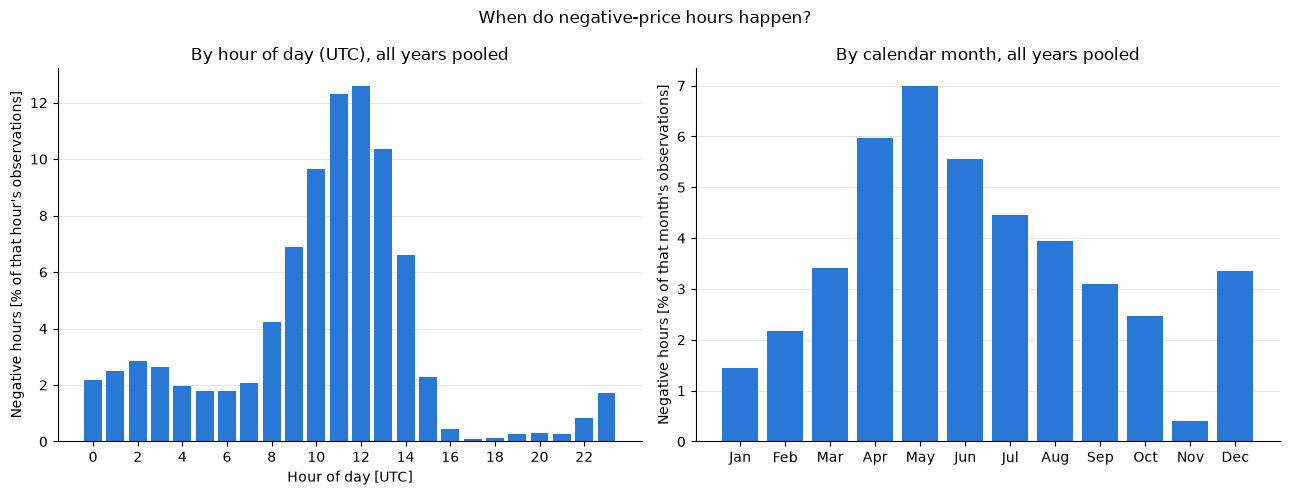

In [4]:
hour_share = is_neg.groupby(is_neg.index.hour).mean().reindex(range(24)) * 100
month_share = is_neg.groupby(is_neg.index.month).mean().reindex(range(1, 13)) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(24), hour_share.values, color=MAIN_COLOR)
axes[0].set_title("By hour of day (UTC), all years pooled")
axes[0].set_xlabel("Hour of day [UTC]")
axes[0].set_ylabel("Negative hours [% of that hour's observations]")
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(MONTH_NAMES, month_share.values, color=MAIN_COLOR)
axes[1].set_title("By calendar month, all years pooled")
axes[1].set_ylabel("Negative hours [% of that month's observations]")

for ax in axes:
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("When do negative-price hours happen?", fontsize=12)
fig.tight_layout()
plt.show()

Negative prices concentrate squarely in the solar-production window
(late morning through mid-afternoon, UTC) and in the sunniest, mildest-
demand months (spring through early autumn) -- the signature of solar
oversupply at low load, not a wind- or winter-driven pattern.

## 3. Has the month-of-year pattern shifted over time?

Same month-of-year view as above, but kept separate per year instead of
pooled, so a shift in *when* during the year negative prices occur (not
just *how often* overall) would show up as a changing column pattern
rather than just a darkening grid.

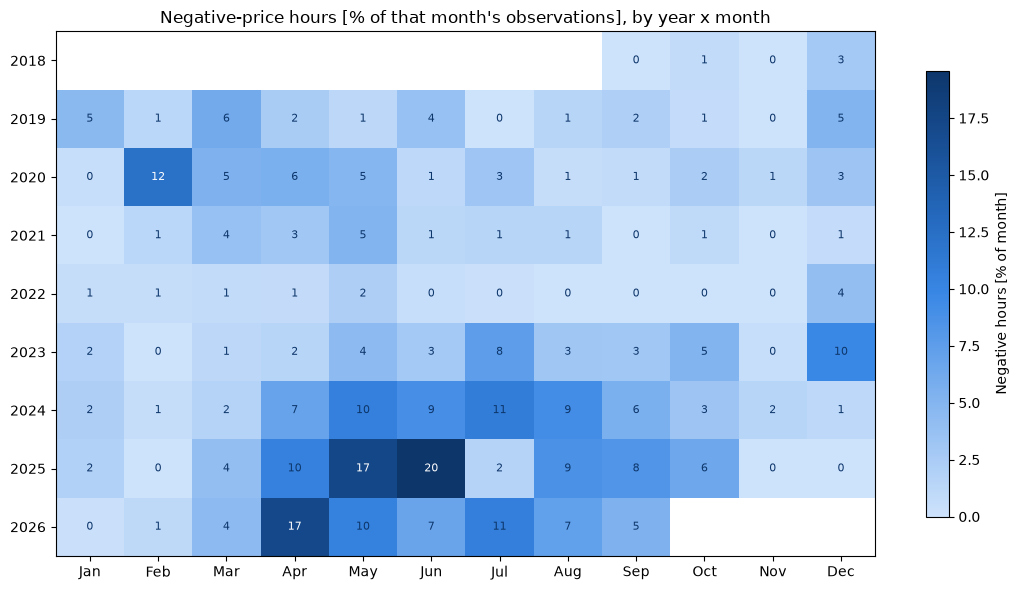

In [5]:
heat = pd.DataFrame({
    "year": is_neg.index.year,
    "month": is_neg.index.month,
    "is_neg": is_neg.values,
}).groupby(["year", "month"])["is_neg"].mean().unstack("month").reindex(columns=range(1, 13)) * 100

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(heat.values, aspect="auto", cmap=MAIN_CMAP, vmin=0)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index.astype(str))
ax.set_title("Negative-price hours [% of that month's observations], by year x month")

# Direct value labels per cell, dark/light text chosen for legibility against
# this single-hue ramp's light-to-dark range; NaN (month outside the series'
# own coverage) left blank.
threshold = np.nanmax(heat.values) * 0.6
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                 color="white" if v > threshold else "#0d366b")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Negative hours [% of month]")
fig.tight_layout()
plt.show()

The pattern isn't just "more of the same" -- it both deepens and widens:
early years show a handful of isolated bright months around spring/summer,
while the most recent years show most months of the year lit up,
including some autumn/winter months that were essentially zero early on.
Growing solar and wind capacity is pushing negative-price conditions
beyond the original April-September window.

## 4. How long do negative-price spells last?

Each maximal run of consecutive negative hours is one "episode". Left:
how many episodes have each length (grouped into a single 11+ bucket --
individual longer lengths are too rare to read as separate bars). Right:
what share of *all* negative hours comes from each length bucket -- since
a few very long episodes can dominate total hours even though they're
rare as episodes.

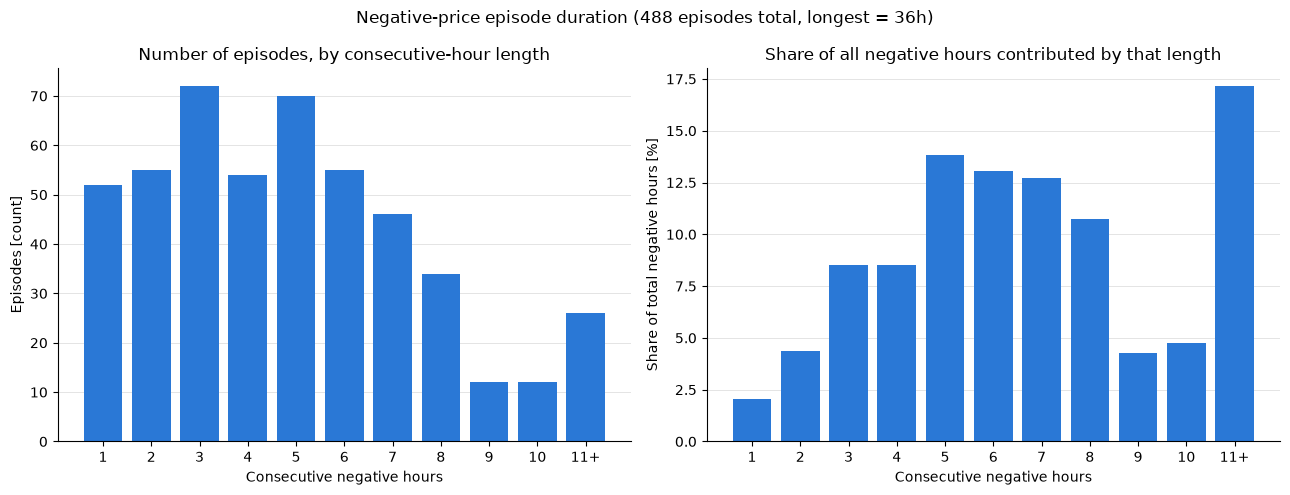

488 episodes, median length 5h, mean 5.2h, longest 36h
Episodes of 10h or shorter: 94.7% of all episodes
...but only 82.8% of all negative hours
The 11+ bucket: 26 episodes (5.3% of episodes) account for 17.2% of all negative hours


In [6]:
neg_int = is_neg.astype(int)
run_id = (neg_int != neg_int.shift()).cumsum()
runs = neg_int.groupby(run_id).agg(is_neg="first", length="size")
episode_lengths = runs.loc[runs["is_neg"] == 1, "length"]

bucket_labels = [str(n) for n in range(1, 11)] + ["11+"]
buckets = pd.cut(episode_lengths, bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.inf], labels=bucket_labels)

episode_counts = buckets.value_counts().reindex(bucket_labels)
hours_by_bucket = episode_lengths.groupby(buckets).sum().reindex(bucket_labels)
hours_share_pct = hours_by_bucket / episode_lengths.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(bucket_labels, episode_counts.values, color=MAIN_COLOR)
axes[0].set_title("Number of episodes, by consecutive-hour length")
axes[0].set_xlabel("Consecutive negative hours")
axes[0].set_ylabel("Episodes [count]")

axes[1].bar(bucket_labels, hours_share_pct.values, color=MAIN_COLOR)
axes[1].set_title("Share of all negative hours contributed by that length")
axes[1].set_xlabel("Consecutive negative hours")
axes[1].set_ylabel("Share of total negative hours [%]")

for ax in axes:
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Negative-price episode duration ({len(episode_lengths)} episodes total, longest = {episode_lengths.max()}h)",
             fontsize=12)
fig.tight_layout()
plt.show()

print(f"{len(episode_lengths)} episodes, median length {episode_lengths.median():.0f}h, "
      f"mean {episode_lengths.mean():.1f}h, longest {episode_lengths.max()}h")
print(f"Episodes of 10h or shorter: {(episode_lengths <= 10).mean() * 100:.1f}% of all episodes")
print(f"...but only {hours_by_bucket[bucket_labels[:10]].sum() / episode_lengths.sum() * 100:.1f}% of all negative hours")
print(f"The 11+ bucket: {episode_counts['11+']} episodes ({episode_counts['11+'] / len(episode_lengths) * 100:.1f}% of episodes) "
      f"account for {hours_share_pct['11+']:.1f}% of all negative hours")

A single isolated negative hour is actually one of the *least* common
outcomes, not the typical case: the median episode already runs several
hours, and the roughly 5% of episodes that stretch past 10 hours in a row
make up a sizeable share of all negative hours on their own. Negative
prices in Germany mostly arrive as multi-hour midday/afternoon blocks,
not as scattered single-hour blips. The left panel above counts each such
block once, by its length; the right panel instead counts the hours it
contributes, which is why a handful of long, rare blocks can dominate the
right panel while barely registering in the left one.